# FishAI Common Global Model Training (Colab + VS Code)

This notebook is Colab-style, but runs directly in VS Code Jupyter as well.

Flow: data load -> cleaning -> preprocessing -> multi-model training -> best model selection -> save artifacts.

In [25]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
import joblib

RANDOM_STATE = 42
BOAT_TYPE_TARGET = None  # Keep None for global model

NOTEBOOK_DIR = Path.cwd()

# Resolve project root robustly for VS Code + Colab runtimes
project_root_candidates = [
    NOTEBOOK_DIR,
    NOTEBOOK_DIR / 'model' / 'cost_prediction',
    Path('/content/final_year_research/model/cost_prediction'),
]
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    project_root_candidates.append(parent)

PROJECT_ROOT = None
for candidate in project_root_candidates:
    if (candidate / 'training_data').exists() or (candidate / 'models').exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = NOTEBOOK_DIR

MODEL_ROOT = PROJECT_ROOT / 'models'
DATA_CANDIDATES = [
    PROJECT_ROOT / 'training_data' / 'training_data_all.csv',
    PROJECT_ROOT / 'data' / 'training_candidates_export.csv',
]

print('Notebook dir:', NOTEBOOK_DIR)
print('Project root:', PROJECT_ROOT)

Notebook dir: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\colab
Project root: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction


In [26]:
def find_data_file(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError('No dataset found. Checked: ' + ', '.join(str(x) for x in paths))

def normalize_schema(df):
    rename_map = {}

    column_aliases = {
        'feature_distanceKm': 'distanceKm',
        'feature_speed': 'speed',
        'feature_engineHP': 'engineHP',
        'feature_fishingHours': 'fishingHours',
        'feature_weatherSeverityIndex': 'weatherSeverityIndex',
        'label_actualFuelLiters': 'fuelUsedLiters',
        'engineHorsePower': 'engineHP',
        'windSpeed': 'weatherSeverityIndex',
        'actualFuelLiters': 'fuelUsedLiters',
    }
    for source_name, target_name in column_aliases.items():
        if source_name in df.columns and target_name not in df.columns:
            rename_map[source_name] = target_name

    if rename_map:
        df = df.rename(columns=rename_map)
        print('Renamed columns:', rename_map)

    required_columns = [
        'distanceKm',
        'speed',
        'engineHP',
        'fishingHours',
        'weatherSeverityIndex',
        'fuelUsedLiters',
    ]
    missing_required = [c for c in required_columns if c not in df.columns]
    if missing_required:
        raise ValueError(
            'Missing required training column(s): ' + ', '.join(missing_required) +
            '. Export real training data with these fields instead of using default values.'
        )

    return df

data_file = find_data_file(DATA_CANDIDATES)
df = pd.read_csv(data_file)
df = normalize_schema(df)

print('Dataset selected:', data_file)
print('Shape before filtering:', df.shape)
df.head()


Renamed columns: {'feature_distanceKm': 'distanceKm', 'feature_speed': 'speed', 'feature_engineHP': 'engineHP', 'feature_fishingHours': 'fishingHours', 'feature_weatherSeverityIndex': 'weatherSeverityIndex', 'label_actualFuelLiters': 'fuelUsedLiters'}
Dataset selected: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\training_data\training_data_all.csv
Shape before filtering: (228, 12)


,boat_type,source_trip_id,boat_id,speed,weatherSeverityIndex,distanceKm,engineHP,fishingHours,feature_numberOfDays,feature_predictedFuelLiters,fuelUsedLiters,label_actualCost
0,IDAT,69e9028a33e21724b91f2021,69e901ce33e21724b91f200e,7.7,0.406933,101.850,68.0,23,1,205.89065,231.4,9.269000e+04
1,OFRP,69ea4731932ab2eec9ec1ed9,69ea46bd932ab2eec9ec1ec5,8.2,0.276000,49.980,22.3,12,1,46.50536,31.8,2.283000e+04
2,IMUI,69ea47eb932ab2eec9ec1f0f,69ea477f932ab2eec9ec1ef9,6.3,0.486333,277.305,125.5,9,2,247.62206,841.2,3.261200e+05
3,MTRP,69ea4e03932ab2eec9ec1f67,69ea4834932ab2eec9ec1f20,6.8,0.450000,210.000,221.3,120,8,3302.77991,1020.0,3.115437e+06
4,IMUI,69f43b23ad93b09dd40f756d,69ea477f932ab2eec9ec1ef9,10.0,0.273333,78.750,125.5,24,2,508.70000,1168.0,4.505000e+05


In [27]:
FEATURES = ['distanceKm', 'speed', 'engineHP', 'fishingHours', 'weatherSeverityIndex']
TARGET = 'fuelUsedLiters'

missing_required = [c for c in FEATURES + [TARGET] if c not in df.columns]
if missing_required:
    raise ValueError(
        'Missing required training column(s): ' + ', '.join(missing_required) +
        '. Re-export real training data before training this model.'
    )

for c in FEATURES + [TARGET]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=FEATURES + [TARGET]).copy()

q1 = df[TARGET].quantile(0.25)
q3 = df[TARGET].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr
df = df[(df[TARGET] >= low) & (df[TARGET] <= high)].copy()

if df.empty:
    raise ValueError(f'No rows left after cleaning from {data_file}.')

MIN_ROWS_FOR_TRAINING = 10
if len(df) < MIN_ROWS_FOR_TRAINING:
    raise ValueError(
        f'Insufficient data for global model: only {len(df)} row(s) remain after cleaning from {data_file}. '
        f'Need at least {MIN_ROWS_FOR_TRAINING} rows to train and evaluate safely.'
    )

print('Shape after cleaning:', df.shape)
df[FEATURES + [TARGET]].describe().T


Shape after cleaning: (228, 12)


,count,mean,std,min,25%,50%,75%,max
distanceKm,228.0,117.079241,77.301674,25.00,50.000,82.65,200.00,277.305
speed,228.0,10.178509,3.187106,6.00,7.600,9.70,13.60,16.400
engineHP,228.0,130.081579,91.447150,12.00,68.000,92.00,220.00,330.000
fishingHours,228.0,24.938596,16.664497,7.00,10.750,20.00,41.25,120.000
weatherSeverityIndex,228.0,0.426488,0.103658,0.22,0.360,0.42,0.50,0.660
fuelUsedLiters,228.0,654.069298,606.717322,28.00,198.925,356.30,1252.50,2000.000


In [28]:
X = df[FEATURES]
y = df[TARGET]

training_mode = 'split'
test_size = 0.2 if len(df) >= 50 else 0.25
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=RANDOM_STATE
)

models = {
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

rows = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / np.maximum(np.abs(y_test), 1e-9))) * 100

    trained_models[name] = model
    rows.append({'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape})

metrics_df = pd.DataFrame(rows).sort_values('MAPE').reset_index(drop=True)
metrics_df

,model,MAE,RMSE,R2,MAPE
0,ExtraTrees,7.023978,13.556609,0.999380,1.150028
1,RandomForest,8.837040,15.183028,0.999222,1.830682
2,GradientBoosting,10.005902,18.655580,0.998825,2.011722
3,HistGradientBoosting,14.950916,23.084489,0.998202,3.580778


## Research Panel Verification

This section answers the common panel questions: how the results were verified, how we know the solution works, which metrics were used, and whether the model generalizes beyond one train/test split.



In [29]:
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.metrics import make_scorer


def mape_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-9))) * 100


cv_splits = min(5, len(df))
cv_repeats = 5 if len(df) >= 20 else 3
cv = RepeatedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=RANDOM_STATE)

scoring = {
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'RMSE': make_scorer(lambda y_true, y_pred: mean_squared_error(y_true, y_pred) ** 0.5, greater_is_better=False),
    'R2': make_scorer(r2_score),
    'MAPE': make_scorer(mape_score, greater_is_better=False),
}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score='raise',
    )
    cv_rows.append({
        'model': name,
        'CV_MAE_MEAN': -scores['test_MAE'].mean(),
        'CV_MAE_STD': scores['test_MAE'].std(),
        'CV_RMSE_MEAN': -scores['test_RMSE'].mean(),
        'CV_RMSE_STD': scores['test_RMSE'].std(),
        'CV_R2_MEAN': scores['test_R2'].mean(),
        'CV_R2_STD': scores['test_R2'].std(),
        'CV_MAPE_MEAN': -scores['test_MAPE'].mean(),
        'CV_MAPE_STD': scores['test_MAPE'].std(),
    })

cv_metrics_df = pd.DataFrame(cv_rows).sort_values('CV_MAPE_MEAN').reset_index(drop=True)
cv_best_model_name = cv_metrics_df.iloc[0]['model']
holdout_best_model_name = (
    best_model_name
    if 'best_model_name' in globals()
    else metrics_df.sort_values('MAPE').iloc[0]['model']
)

print('Verification method: holdout test split + repeated k-fold cross-validation')
print(f'CV setup: {cv_splits} folds x {cv_repeats} repeats = {cv_splits * cv_repeats} validation runs per model')
print('Metrics used: MAE, RMSE, R2, MAPE')
print('Best model by holdout MAPE:', holdout_best_model_name)
print('Best model by repeated CV MAPE:', cv_best_model_name)

if cv_best_model_name != holdout_best_model_name:
    print('Note: holdout and CV select different models. Prefer CV result in the research discussion, especially for small datasets.')

cv_metrics_df




Verification method: holdout test split + repeated k-fold cross-validation
CV setup: 5 folds x 5 repeats = 25 validation runs per model
Metrics used: MAE, RMSE, R2, MAPE
Best model by holdout MAPE: ExtraTrees
Best model by repeated CV MAPE: ExtraTrees


,model,CV_MAE_MEAN,CV_MAE_STD,CV_RMSE_MEAN,CV_RMSE_STD,CV_R2_MEAN,CV_R2_STD,CV_MAPE_MEAN,CV_MAPE_STD
0,ExtraTrees,12.601221,6.753937,42.583086,39.118758,0.990714,0.014030,2.289048,1.218340
1,RandomForest,17.117205,7.674205,49.447031,39.061859,0.988953,0.015166,3.534253,1.323276
2,GradientBoosting,17.235668,7.847545,49.848963,37.237740,0.989203,0.013634,3.636349,1.548863
3,HistGradientBoosting,26.494085,8.672932,58.510215,33.678448,0.987407,0.014028,7.169396,2.950592


In [30]:
best_model_name = metrics_df.iloc[0]['model']
best_model = trained_models[best_model_name]

target_dir = MODEL_ROOT / 'fishtripcost' / 'global' / 'best_model'
target_dir.mkdir(parents=True, exist_ok=True)

model_file = target_dir / 'fuel_model.pkl'
meta_file = target_dir / 'metadata.json'

joblib.dump(best_model, model_file)

metadata = {
    'scope': 'GLOBAL',
    'boat_type': None,
    'dataset': str(data_file),
    'features': FEATURES,
    'target': TARGET,
    'selected_model': best_model_name,
    'ranking': metrics_df.to_dict(orient='records'),
    'selection_metric': 'holdout_mape',
    'verification_method': 'holdout test split plus repeated k-fold cross-validation',
    'cross_validation': cv_metrics_df.to_dict(orient='records') if 'cv_metrics_df' in globals() else [],
    'cv_best_model': cv_best_model_name if 'cv_best_model_name' in globals() else None,
    'metrics_used': ['MAE', 'RMSE', 'R2', 'MAPE'],
    'training_mode': training_mode,
    'rows_used': int(len(df)),
}
reports_dir = target_dir / 'reports'
reports_dir.mkdir(parents=True, exist_ok=True)
if 'cv_metrics_df' in globals():
    cv_metrics_df.to_csv(reports_dir / 'cross_validation_metrics.csv', index=False)

meta_file.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print('Saved model to:', model_file)
print('Saved metadata to:', meta_file)


Saved model to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\global\best_model\fuel_model.pkl
Saved metadata to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\global\best_model\metadata.json


In [31]:
sample = X_test.head(1)
pred = float(best_model.predict(sample)[0])
print('Sample input:')
print(sample)
print('Predicted fuel liters:', round(pred, 3))

Sample input:
     distanceKm  speed  engineHP  fishingHours  weatherSeverityIndex
215        67.0   16.1     125.0            12                  0.42
Predicted fuel liters: 464.05


In [32]:
import subprocess
import sys

# Install tensorflow in the current kernel environment
print("Installing TensorFlow...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorflow"])
print("TensorFlow installed successfully")

Installing TensorFlow...
TensorFlow installed successfully


In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

# Check if we have enough data for neural network training
if len(X_train) < 5:
    print(f'Warning: Only {len(X_train)} training sample(s). Skipping neural network training (requires minimum 5 samples).')
    history = None
else:
    # Normalize features for neural network training
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Build neural network model
    nn_model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(len(FEATURES),)),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    nn_model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    # Determine validation split based on available data
    if len(X_train) < 10:
        validation_split = None
        # Train on all data without validation split
        history = nn_model.fit(
            X_train_scaled,
            y_train,
            epochs=25,
            batch_size=1,
            verbose=0
        )
        print('Neural Network Training Complete (all data used for training)')
        print('Best training MAE:', round(min(history.history['mae']), 3))
    else:
        validation_split = 0.2
        history = nn_model.fit(
            X_train_scaled,
            y_train,
            epochs=25,
            batch_size=8,
            validation_split=validation_split,
            verbose=0
        )
        print('Neural Network Training Complete')
        print('Best validation MAE:', round(min(history.history['val_mae']), 3))

C:\Users\Piuminda Jayaweera\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network Training Complete
Best validation MAE: 34.582


[Neural Network Evaluation]
  R² Score: 0.9928
  MAE: 35.51
  RMSE: 46.17
  MAPE: 11.23%


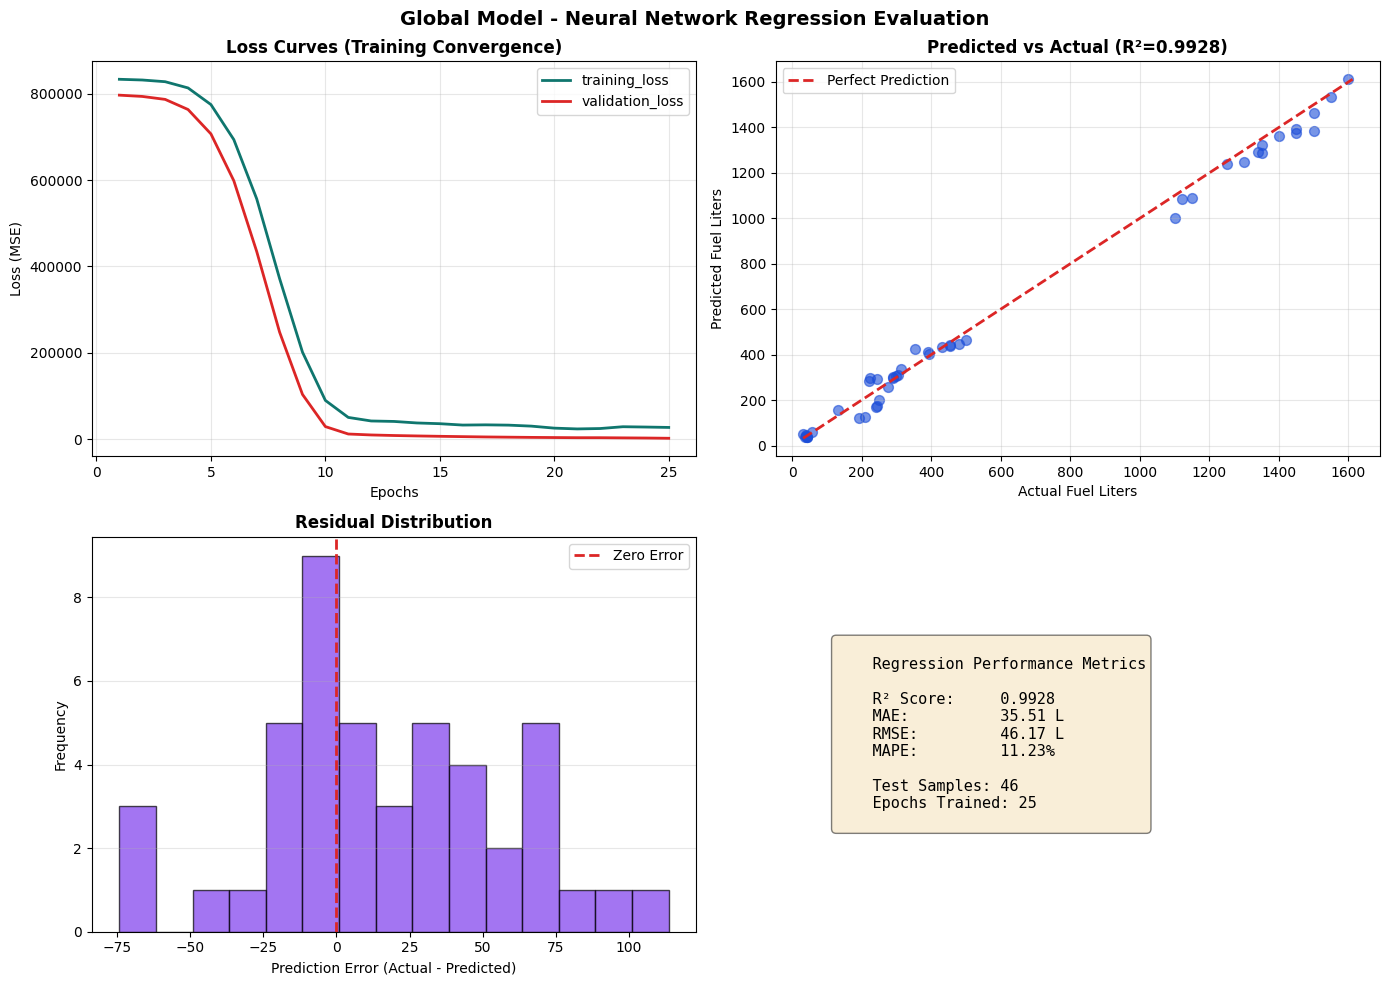


Saved neural network evaluation plots to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\global\best_model\reports\figures\neural_network_regression_evaluation.png


In [34]:
# ==============================
# NEURAL NETWORK EVALUATION & VISUALIZATION
# ==============================

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Setup figure directory if not already done
report_dir = target_dir / 'reports'
figure_dir = report_dir / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)

if history is None:
    print('Skipping graph generation: insufficient training data for neural network')
else:
    # Get predictions on test set
    y_pred_nn = nn_model.predict(X_test_scaled, verbose=0)
    y_pred_nn = y_pred_nn.flatten()
    
    # Calculate proper regression metrics
    nn_r2 = r2_score(y_test, y_pred_nn)
    nn_mae = mean_absolute_error(y_test, y_pred_nn)
    nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
    nn_mape = np.mean(np.abs((y_test - y_pred_nn) / np.maximum(np.abs(y_test), 1e-9))) * 100
    
    print('[Neural Network Evaluation]')
    print(f'  R² Score: {nn_r2:.4f}')
    print(f'  MAE: {nn_mae:.2f}')
    print(f'  RMSE: {nn_rmse:.2f}')
    print(f'  MAPE: {nn_mape:.2f}%')
    
    # ==============================
    # PLOT 1: Loss Curves (Training Convergence)
    # PLOT 2: Predicted vs Actual (Regression Quality)
    # PLOT 3: Residuals (Error Distribution)
    # PLOT 4: Metrics Summary
    # ==============================
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Global Model - Neural Network Regression Evaluation', fontsize=14, fontweight='bold')
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    # --- SUBPLOT 1: Training Loss Curves ---
    train_loss = pd.Series(history.history['loss']).rolling(3, min_periods=1).mean()
    axes[0, 0].plot(epochs, train_loss, label='training_loss', linewidth=2, color='#0f766e')
    
    if 'val_loss' in history.history:
        val_loss = pd.Series(history.history['val_loss']).rolling(3, min_periods=1).mean()
        axes[0, 0].plot(epochs, val_loss, label='validation_loss', linewidth=2, color='#dc2626')
    
    axes[0, 0].set_title('Loss Curves (Training Convergence)', fontweight='bold')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss (MSE)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # --- SUBPLOT 2: Predicted vs Actual (CRITICAL FOR REGRESSION) ---
    min_val = min(y_test.min(), y_pred_nn.min())
    max_val = max(y_test.max(), y_pred_nn.max())
    
    axes[0, 1].scatter(y_test, y_pred_nn, alpha=0.6, s=50, color='#1d4ed8')
    axes[0, 1].plot([min_val, max_val], [min_val, max_val], '--', color='#dc2626', linewidth=2, label='Perfect Prediction')
    axes[0, 1].set_title(f'Predicted vs Actual (R²={nn_r2:.4f})', fontweight='bold')
    axes[0, 1].set_xlabel('Actual Fuel Liters')
    axes[0, 1].set_ylabel('Predicted Fuel Liters')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # --- SUBPLOT 3: Residual Distribution ---
    residuals = y_test.values - y_pred_nn
    residual_bins = max(5, min(15, len(y_test) // 2))
    axes[1, 0].hist(residuals, bins=residual_bins, color='#7c3aed', alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(0, color='#dc2626', linestyle='--', linewidth=2, label='Zero Error')
    axes[1, 0].set_title('Residual Distribution', fontweight='bold')
    axes[1, 0].set_xlabel('Prediction Error (Actual - Predicted)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # --- SUBPLOT 4: Regression Metrics Summary ---
    metrics_text = f'''
    Regression Performance Metrics
    
    R² Score:     {nn_r2:.4f}
    MAE:          {nn_mae:.2f} L
    RMSE:         {nn_rmse:.2f} L
    MAPE:         {nn_mape:.2f}%
    
    Test Samples: {len(y_test)}
    Epochs Trained: {len(history.history['loss'])}
    '''
    
    axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=11, verticalalignment='center',
                    family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure
    nn_figure_path = figure_dir / 'neural_network_regression_evaluation.png'
    fig.savefig(nn_figure_path, dpi=160, bbox_inches='tight')
    print(f'\nSaved neural network evaluation plots to: {nn_figure_path}')

In [35]:
# ==============================
# SAVE NEURAL NETWORK MODEL
# ==============================

if history is None:
    print('Skipping neural network model save: insufficient training data')
else:
    # Save the neural network model as pickle directly in model storage folder
    nn_model_path = target_dir / 'global_neural_network_model.pkl'
    import pickle
    with open(nn_model_path, 'wb') as f:
        pickle.dump(nn_model, f)

    # Save model metrics
    nn_metrics = {
        'model_type': 'neural_network',
        'model_scope': 'global',
        'r2_score': float(nn_r2),
        'mae': float(nn_mae),
        'rmse': float(nn_rmse),
        'mape': float(nn_mape),
        'test_samples': int(len(y_test)),
        'epochs_trained': int(len(history.history['loss']))
    }

    nn_metrics_file = target_dir / 'neural_network_metrics.json'
    nn_metrics_file.write_text(json.dumps(nn_metrics, indent=2), encoding='utf-8')

    print(f'Saved neural network model to: {nn_model_path}')
    print(f'Saved neural network metrics to: {nn_metrics_file}')

Saved neural network model to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\global\best_model\global_neural_network_model.pkl
Saved neural network metrics to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\global\best_model\neural_network_metrics.json


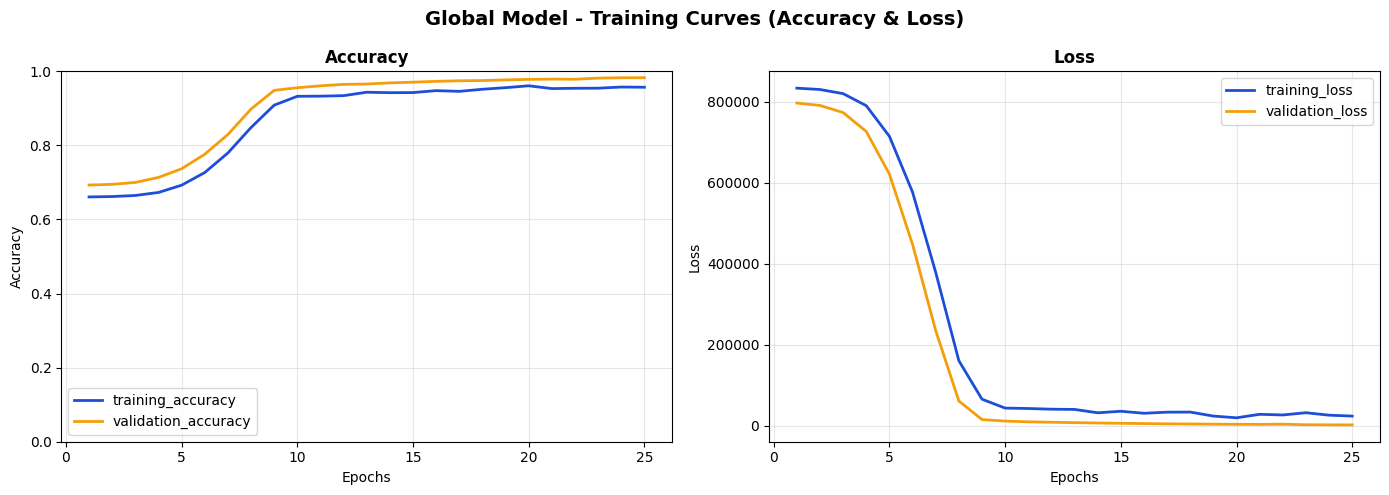

Saved simple accuracy & loss graphs to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\global\best_model\reports\figures\training_accuracy_loss.png


In [36]:
# ==============================
# SIMPLE 2-PANEL: TRAINING CURVES (Quick Overview)
# ==============================

if history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Global Model - Training Curves (Accuracy & Loss)', fontsize=14, fontweight='bold')
    
    epochs = range(1, len(history.history['loss']) + 1)
    y_train_max = y_train.max()
    
    # --- LEFT: Accuracy ---
    train_accuracy = 1.0 - (np.array(history.history['mae']) / y_train_max)
    train_accuracy = np.clip(train_accuracy, 0, 1)
    val_accuracy = 1.0 - (np.array(history.history['val_mae']) / y_train_max)
    val_accuracy = np.clip(val_accuracy, 0, 1)
    
    axes[0].plot(epochs, train_accuracy, label='training_accuracy', linewidth=2, color='#1d4ed8')
    axes[0].plot(epochs, val_accuracy, label='validation_accuracy', linewidth=2, color='#f59e0b')
    axes[0].set_title('Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # --- RIGHT: Loss ---
    axes[1].plot(epochs, history.history['loss'], label='training_loss', linewidth=2, color='#1d4ed8')
    axes[1].plot(epochs, history.history['val_loss'], label='validation_loss', linewidth=2, color='#f59e0b')
    axes[1].set_title('Loss', fontweight='bold')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure
    simple_figure_path = figure_dir / 'training_accuracy_loss.png'
    fig.savefig(simple_figure_path, dpi=160, bbox_inches='tight')
    print(f'Saved simple accuracy & loss graphs to: {simple_figure_path}')